In [9]:
# STEP 1: DATA COLLECTION
print("=" * 60)
print("SHADAWA PASTORALIST WOMEN MEDIA EMPOWERMENT ANALYSIS")
print("Round 1 Data - IDRC-SPARC-FUDECO Research")
print("=" * 60)

# Raw data from Table 1 & 2 of the report
# Format: "MediaName:FemaleYes,MaleYes,TotalYes|NextMedia:..."
raw_data = "Radio:18,13,31|Television:1,4,5|WhatsApp:5,4,9|Facebook/YouTube/TikTok:6,5,11|Internet/Website:1,3,4|Newspapers:1,3,4|Telephone:5,11,16|POS:4,6,10"

print("\nRaw data collected successfully.")

# STEP 2: DATA CLEANING
entries = raw_data.split("|")
print("\nSplit by pipe (|):")
print(entries)

# Initialize empty lists
media_types = []
females_yes = []
males_yes = []
total_yes = []

# Loop through each entry and extract the numbers
for entry in entries:
    # Split into media name and the numbers
    parts = entry.split(":")
    media_name = parts[0]
    numbers = parts[1].split(",")
    
    # Add to our lists
    media_types.append(media_name)
    females_yes.append(int(numbers[0]))
    males_yes.append(int(numbers[1]))
    total_yes.append(int(numbers[2]))

print("\n" + "=" * 60)
print("CLEAN DATA")
print("=" * 60)
print("Media Types:", media_types)
print("\nFemales (Yes):", females_yes)
print("Males (Yes):", males_yes)
print("Total (Yes):", total_yes)

SHADAWA PASTORALIST WOMEN MEDIA EMPOWERMENT ANALYSIS
Round 1 Data - IDRC-SPARC-FUDECO Research

Raw data collected successfully.

Split by pipe (|):
['Radio:18,13,31', 'Television:1,4,5', 'WhatsApp:5,4,9', 'Facebook/YouTube/TikTok:6,5,11', 'Internet/Website:1,3,4', 'Newspapers:1,3,4', 'Telephone:5,11,16', 'POS:4,6,10']

CLEAN DATA
Media Types: ['Radio', 'Television', 'WhatsApp', 'Facebook/YouTube/TikTok', 'Internet/Website', 'Newspapers', 'Telephone', 'POS']

Females (Yes): [18, 1, 5, 6, 1, 1, 5, 4]
Males (Yes): [13, 4, 4, 5, 3, 3, 11, 6]
Total (Yes): [31, 5, 9, 11, 4, 4, 16, 10]


In [10]:
# STEP 3: DATA ANALYSIS & EXPLORATION

print("=" * 60)
print("ANALYSIS: MEDIA ACCESS IN SHADAWA")
print("=" * 60)

# --- ANALYSIS 1: Which media is most used overall? ---
max_total = max(total_yes)
max_index = total_yes.index(max_total)
print(f"\nMost Used Media (Total): {media_types[max_index]} - {max_total} respondents ({(max_total/50)*100:.1f}%)")

# --- ANALYSIS 2: Which media is least used overall? ---
min_total = min(total_yes)
min_index = total_yes.index(min_total)
print(f"\nLeast Used Media (Total): {media_types[min_index]} - {min_total} respondents ({(min_total/50)*100:.1f}%)")

# --- ANALYSIS 3: Which media is most used by WOMEN? ---
max_female = max(females_yes)
max_female_index = females_yes.index(max_female)
print(f"\nMost Used Media by WOMEN: {media_types[max_female_index]} - {max_female} women ({(max_female/36)*100:.1f}%)")

# --- ANALYSIS 4: Which media is most used by MEN? ---
max_male = max(males_yes)
max_male_index = males_yes.index(max_male)
print(f"\nMost Used Media by MEN: {media_types[max_male_index]} - {max_male} men ({(max_male/14)*100:.1f}%)")

# --- ANALYSIS 5: The Gender Gap in Radio Access ---
radio_female_pct = (females_yes[0] / 36) * 100
radio_male_pct = (males_yes[0] / 14) * 100
print(f"\n--- GENDER GAP IN RADIO ACCESS ---")
print(f"Women who listen to Radio: {radio_female_pct:.1f}%")
print(f"Men who listen to Radio: {radio_male_pct:.1f}%")
print(f"Gap: {radio_male_pct - radio_female_pct:.1f}% more men than women")

# --- ANALYSIS 6: Telephone Access Gap (Critical for Media Empowerment) ---
phone_female_pct = (females_yes[6] / 36) * 100
phone_male_pct = (males_yes[6] / 14) * 100
print(f"\n--- GENDER GAP IN TELEPHONE ACCESS ---")
print(f"Women with Telephone: {phone_female_pct:.1f}%")
print(f"Men with Telephone: {phone_male_pct:.1f}%")
print(f"Gap: {phone_male_pct - phone_female_pct:.1f}% more men than women")

# --- ANALYSIS 7: Digital Divide (Internet + Social Media) ---
print(f"\n--- DIGITAL DIVIDE ---")
print(f"Women with Internet Access: {(females_yes[4]/36)*100:.1f}%")
print(f"Men with Internet Access: {(males_yes[4]/14)*100:.1f}%")
print(f"Women who heard of Social Media: {(females_yes[3]/36)*100:.1f}%")
print(f"Men who heard of Social Media: {(males_yes[3]/14)*100:.1f}%")

ANALYSIS: MEDIA ACCESS IN SHADAWA

Most Used Media (Total): Radio - 31 respondents (62.0%)

Least Used Media (Total): Internet/Website - 4 respondents (8.0%)

Most Used Media by WOMEN: Radio - 18 women (50.0%)

Most Used Media by MEN: Radio - 13 men (92.9%)

--- GENDER GAP IN RADIO ACCESS ---
Women who listen to Radio: 50.0%
Men who listen to Radio: 92.9%
Gap: 42.9% more men than women

--- GENDER GAP IN TELEPHONE ACCESS ---
Women with Telephone: 13.9%
Men with Telephone: 78.6%
Gap: 64.7% more men than women

--- DIGITAL DIVIDE ---
Women with Internet Access: 2.8%
Men with Internet Access: 21.4%
Women who heard of Social Media: 16.7%
Men who heard of Social Media: 35.7%


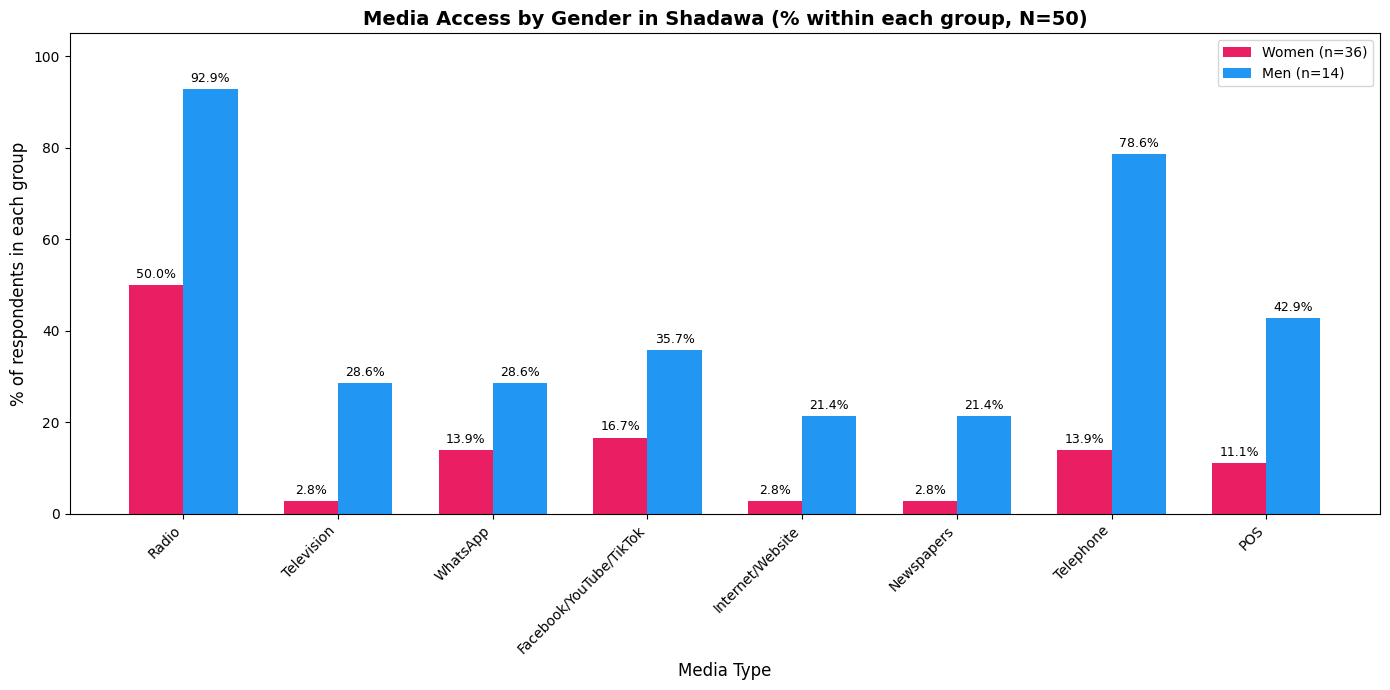

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np

n_women, n_men = 36, 14

# Percentage within each group
female_pct = [v / n_women * 100 for v in females_yes]
male_pct = [v / n_men * 100 for v in males_yes]

x = np.arange(len(media_types))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
bars1 = ax.bar(x - width/2, female_pct, width, label=f'Women (n={n_women})', color='#e91e63')
bars2 = ax.bar(x + width/2, male_pct, width, label=f'Men (n={n_men})', color='#2196f3')

ax.set_xlabel('Media Type', fontsize=12)
ax.set_ylabel('% of respondents in each group', fontsize=12)
ax.set_title('Media Access by Gender in Shadawa (% within each group, N=50)',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(media_types, rotation=45, ha='right')
ax.set_ylim(0, 105)
ax.legend()

# Value labels on top of bars
for bars in (bars1, bars2):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save for the README (before plt.show)
os.makedirs('images', exist_ok=True)
plt.savefig('images/media-access-by-gender.png', dpi=150, bbox_inches='tight')
plt.show()

# Shadawa Pastoralist Women Media Empowerment Analysis
### A Data Analyst's Report for FUDECO

**Methodology:**
Analyzed Round 1 IDRC-SPARC-FUDECO research data from Shadawa pastoralist settlement (N=50). Data was cleaned, analyzed, and visualized using Python to identify media access patterns and gender gaps.

**Key Findings:**

| Media Type | Females (Yes) | Males (Yes) | Total (Yes) | % of Total |
| :--- | :--- | :--- | :--- | :--- |
| Radio | 18 | 13 | 31 | 62% |
| Telephone | 5 | 11 | 16 | 32% |
| Facebook/YouTube/TikTok | 6 | 5 | 11 | 22% |
| POS | 4 | 6 | 10 | 20% |
| WhatsApp | 5 | 4 | 9 | 18% |
| Television | 1 | 4 | 5 | 10% |
| Internet/Website | 1 | 3 | 4 | 8% |
| Newspapers | 1 | 3 | 4 | 8% |

**Insights:**

1. **Radio is the Gateway:** Radio is the most used medium (62%) and the only channel with significant reach among women (50%). It is the most viable channel for the media empowerment project.

2. **Telephone Gender Gap:** There is a 64.7 percentage point gap in telephone access between men (78.6%) and women (13.9%). This is a major barrier to any mobile-based intervention.

3. **Digital Divide:** Only 2.8% of women have internet access, and only 16.7% have heard of social media. Digital-first strategies are unlikely to reach women.

4. **Women trail men on every channel:** Women's raw counts for radio (18 vs 13) and social media awareness (6 vs 5) look similar only because women are 36 of the 50 respondents. As a share of each group, women are behind men on every channel, for example radio 50.0% vs 92.9%.

**Recommendations:**

1. **Prioritize Radio:** Design the media empowerment project around radio programming in Fulfulde and Hausa.
2. **Address Telephone Access:** Explore community phone-sharing models or subsidized handsets for women.
3. **Digital Literacy Component:** Include basic digital literacy training, but do not rely on it as the primary channel.
4. **Engage Men as Allies:** Since men control access to many resources, include them in awareness and buy-in sessions.

**Note on sample size:** The sample is small (N=50, including only 14 men). For men, each respondent represents about 7 percentage points, so male percentages can swing widely. These findings should be treated as indicative, not definitive.